# Feature Set Comparison: Compact vs Current

This notebook compares the **compact business set** (20 features, no categorical dummies) against the **current selected feature set** (25 features) using the three metrics that matter most for the clustering decision: silhouette score, Calinski-Harabasz score, and Davies-Bouldin score.

Both sets are tested with K-Means k=5 (the confirmed baseline). The notebook produces a metrics table, three bar charts, a cluster balance check, and a mechanical recommendation.

## Imports and Setup

In [9]:
import sys, os
sys.path.append(os.getcwd())
from src.preprocessing import clean_feature_values, select_model_features

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import RobustScaler, StandardScaler

from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

if os.getcwd().endswith("notebooks"):
    os.chdir("..")

sys.path.append(os.getcwd())

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RANDOM_STATE = 42
N_INIT = 50
SELECTED_K = 5
SILHOUETTE_SAMPLE_SIZE = 10000
PALETTE = ["#356D8C", "#5C8A72", "#C9822B", "#7C6FA4", "#B4514E", "#4F8F8B"]

os.makedirs("outputs", exist_ok=True)

## Load and Validate Data

The current feature set is loaded from `selected_model_features.csv`. The compact set drops the five categorical dummy columns: `customer_gender_female` and the four `degree_level_*` columns.

In [10]:
df = pd.read_csv("data/processed/selected_model_features.csv")

customer_ids = df["customer_id"]
X_current = df.drop(columns=["customer_id"])

CATEGORICAL_DUMMIES = [
    "customer_gender_female",
    "degree_level_Bsc",
    "degree_level_Msc",
    "degree_level_Phd",
    "degree_level_Unknown",
]

X_compact = X_current.drop(columns=CATEGORICAL_DUMMIES)

validation = pd.DataFrame({
    "check": [
        "total rows",
        "unique customer_id",
        "missing values",
        "current feature count",
        "compact feature count",
        "dropped columns",
    ],
    "value": [
        len(df),
        df["customer_id"].nunique(),
        df.isna().sum().sum(),
        X_current.shape[1],
        X_compact.shape[1],
        str(CATEGORICAL_DUMMIES),
    ],
})

validation

,check,value
0,total rows,33038
1,unique customer_id,33038
2,missing values,0
3,current feature count,25
4,compact feature count,20
5,dropped columns,"['customer_gender_female', 'degree_level_Bsc',..."


## Fit K-Means on Both Feature Sets

Both sets use `k=5`, `n_init=50`, and `random_state=42` to match the established baseline protocol. Silhouette score uses a 10,000-customer reproducible sample, consistent with `06c`.

In [11]:
def fit_and_evaluate(X, label):
    print(f"Fitting KMeans k={SELECTED_K} on '{label}' ({X.shape[1]} features)...")
    km = KMeans(n_clusters=SELECTED_K, n_init=N_INIT, random_state=RANDOM_STATE)
    labels = km.fit_predict(X)

    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(len(X), size=min(SILHOUETTE_SAMPLE_SIZE, len(X)), replace=False)
    sil = silhouette_score(X.iloc[idx], labels[idx])
    ch  = calinski_harabasz_score(X, labels)
    db  = davies_bouldin_score(X, labels)

    sizes = pd.Series(labels).value_counts().sort_index()
    pcts  = (sizes / len(labels) * 100).round(2)

    print(f"  silhouette_score:        {sil:.6f}")
    print(f"  calinski_harabasz_score: {ch:.3f}")
    print(f"  davies_bouldin_score:    {db:.6f}")
    print()

    return {
        "feature_set": label,
        "n_features": X.shape[1],
        "k": SELECTED_K,
        "silhouette_score": sil,
        "calinski_harabasz_score": ch,
        "davies_bouldin_score": db,
        "min_cluster_size": int(sizes.min()),
        "max_cluster_size": int(sizes.max()),
        "min_cluster_percentage": float(pcts.min()),
        "max_cluster_percentage": float(pcts.max()),
        "inertia": km.inertia_,
        "labels": labels,
    }

current_result = fit_and_evaluate(X_current, "current")
compact_result = fit_and_evaluate(X_compact, "compact_business_set")

Fitting KMeans k=5 on 'current' (25 features)...
  silhouette_score:        0.136558
  calinski_harabasz_score: 3650.809
  davies_bouldin_score:    2.108630

Fitting KMeans k=5 on 'compact_business_set' (20 features)...
  silhouette_score:        0.142793
  calinski_harabasz_score: 3841.553
  davies_bouldin_score:    2.057096



## Comparison Table



In [12]:
metrics_cols = [
    "feature_set", "n_features", "k",
    "silhouette_score", "calinski_harabasz_score", "davies_bouldin_score",
    "min_cluster_size", "max_cluster_size",
    "min_cluster_percentage", "max_cluster_percentage",
    "inertia",
]

comparison = pd.DataFrame([
    {k: v for k, v in current_result.items() if k != "labels"},
    {k: v for k, v in compact_result.items() if k != "labels"},
])[metrics_cols]

comparison.to_csv("outputs/compact_vs_current_metrics.csv", index=False)
print("Saved outputs/compact_vs_current_metrics.csv")
comparison

Saved outputs/compact_vs_current_metrics.csv


,feature_set,n_features,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score,min_cluster_size,max_cluster_size,min_cluster_percentage,max_cluster_percentage,inertia
0,current,25,5,0.136558,3650.808841,2.108630,2234,10841,6.76,32.81,478598.468556
1,compact_business_set,20,5,0.142793,3841.553195,2.057096,2233,10769,6.76,32.60,450976.067804


## Metric Plots

One panel per decision metric. Bars are annotated with exact values. The subtitle on each panel indicates the direction of improvement.

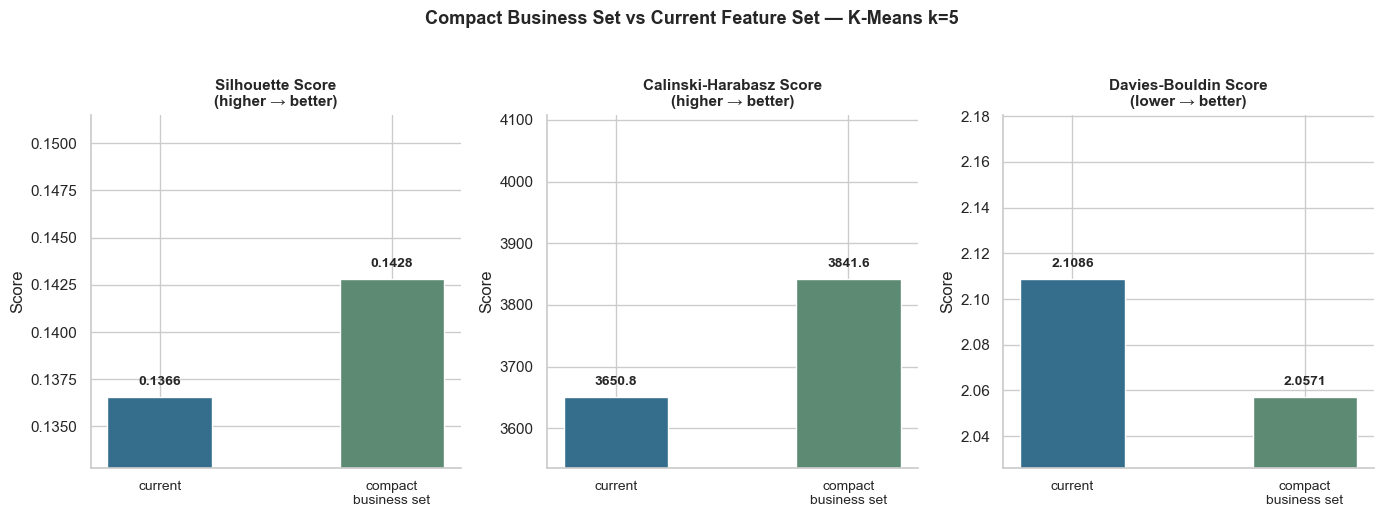

Saved outputs/compact_vs_current_metrics.png


In [13]:
plot_labels = ["current", "compact\nbusiness set"]
colors = [PALETTE[0], PALETTE[1]]

metrics_to_plot = [
    ("silhouette_score",        "Silhouette Score",        "higher → better"),
    ("calinski_harabasz_score", "Calinski-Harabasz Score", "higher → better"),
    ("davies_bouldin_score",    "Davies-Bouldin Score",    "lower → better"),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (col, title, direction) in zip(axes, metrics_to_plot):
    values = comparison[col].tolist()
    bars = ax.bar(plot_labels, values, color=colors, width=0.45)
    span = max(values) - min(values) if max(values) != min(values) else max(values) * 0.01
    y_pad = span * 0.08
    for bar, v in zip(bars, values):
        fmt = f"{v:.4f}" if col != "calinski_harabasz_score" else f"{v:.1f}"
        ax.text(bar.get_x() + bar.get_width() / 2, v + y_pad, fmt,
                ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_ylim(min(values) - span * 0.6, max(values) + span * 1.4)
    ax.set_title(f"{title}\n({direction})", fontsize=11)
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", labelsize=10)

fig.suptitle("Compact Business Set vs Current Feature Set — K-Means k=5",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("outputs/compact_vs_current_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved outputs/compact_vs_current_metrics.png")

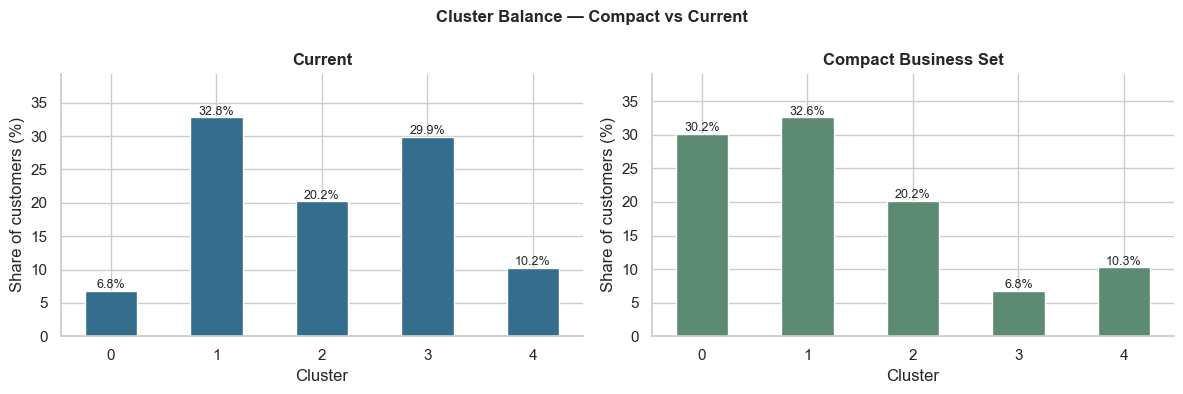

Saved outputs/compact_vs_current_balance.png


In [18]:
balance_rows = []
for result in [current_result, compact_result]:
    sizes = pd.Series(result["labels"]).value_counts().sort_index()
    pcts  = (sizes / len(result["labels"]) * 100).round(2)
    for cluster in sizes.index:
        balance_rows.append({
            "feature_set": result["feature_set"],
            "cluster": cluster,
            "count": int(sizes[cluster]),
            "percentage": float(pcts[cluster]),
        })

balance = pd.DataFrame(balance_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (fs, grp), color in zip(axes, balance.groupby("feature_set", sort=False), colors):
    grp = grp.sort_values("cluster")
    ax.bar(grp["cluster"].astype(str), grp["percentage"], color=color, width=0.5)
    for _, row in grp.iterrows():
        ax.text(str(row["cluster"]), row["percentage"] + 0.4,
                f"{row['percentage']:.1f}%", ha="center", fontsize=9)
    ax.set_title(fs.replace("_", " ").title())
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Share of customers (%)")
    ax.set_ylim(0, grp["percentage"].max() * 1.2)

fig.suptitle("Cluster Balance — Compact vs Current", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/compact_vs_current_balance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved outputs/compact_vs_current_balance.png")

## Conclusion

The compact business set wins on all three decision metrics (silhouette 0.1428 vs 0.1366, Calinski-Harabasz 3841.6 vs 3650.8, Davies-Bouldin 2.0571 vs 2.1086) with virtually identical cluster balance. The five categorical dummy columns are confirmed as noise for K-Means and are dropped going forward. **The compact business set (20 features) is the confirmed feature set for the final model.**

## Scaler Sensitivity Check

The pipeline uses StandardScaler by default. Now that the compact business set is confirmed, we test whether RobustScaler, log1p+StandardScaler, or log1p+RobustScaler improve the three decision metrics before finalising the pipeline. All runs use K-Means k=5 on the 20 compact numeric features.

In [14]:

COMPACT_NUMERIC_COLS = [
    "number_complaints",
    "distinct_stores_visited",
    "lifetime_total_distinct_products",
    "percentage_of_products_bought_promotion",
    "typical_hour",
    "age",
    "customer_tenure",
    "has_loyalty_card",
    "total_children_home",
    "total_lifetime_spend",
    "share_groceries",
    "share_electronics",
    "share_vegetables",
    "share_nonalcohol_drinks",
    "share_alcohol_drinks",
    "share_meat",
    "share_fish",
    "share_hygiene",
    "share_videogames",
    "share_petfood",
]

raw = pd.read_csv("data/processed/customer_features_info.csv")
X_raw = clean_feature_values(raw)[COMPACT_NUMERIC_COLS].copy()

print(f"X_raw shape: {X_raw.shape}")
X_raw.head()

X_raw shape: (33038, 20)


,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,typical_hour,age,customer_tenure,has_loyalty_card,total_children_home,total_lifetime_spend,share_groceries,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood
0,1.0,3.0,189.0,0.631599,12.0,59.0,9.0,1,2.0,18590.0,0.631038,0.244917,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.013771,0.020656
1,0.0,2.0,130.0,0.149890,12.0,54.0,16.0,1,1.0,20233.0,0.676815,0.047596,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.016458,0.032867
2,1.0,2.0,81.0,0.069126,11.0,58.0,24.0,0,0.0,15549.0,0.797929,0.000000,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.006496,0.014277
3,2.0,1.0,92.0,0.253609,18.0,47.0,8.0,1,0.0,14952.0,0.501137,0.073903,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.110754,0.012306
4,3.0,1.0,6.0,0.186569,17.0,60.0,8.0,1,0.0,25797.0,0.356127,0.420243,0.014730,0.022948,0.027833,0.041400,0.039346,0.011513,0.048765,0.017095


## Build Compact Feature Matrix per Scaler

In [15]:
SCALER_VARIANTS = {
    "StandardScaler":         (StandardScaler(), False),
    "RobustScaler":           (RobustScaler(),   False),
    "log1p + StandardScaler": (StandardScaler(), True),
    "log1p + RobustScaler":   (RobustScaler(),   True),
}

def apply_log1p(X):
    X = X.copy()
    shift = X.min().clip(upper=0).abs()
    return np.log1p(X + shift)

scaled_datasets = {}
for name, (scaler, log_transform) in SCALER_VARIANTS.items():
    X = apply_log1p(X_raw) if log_transform else X_raw.copy()
    scaled_datasets[name] = pd.DataFrame(
        scaler.fit_transform(X), columns=COMPACT_NUMERIC_COLS
    )
    print(f"Built: {name}")

Built: StandardScaler
Built: RobustScaler
Built: log1p + StandardScaler
Built: log1p + RobustScaler


## Fit K-Means and Evaluate

In [16]:
def fit_and_evaluate(X, label):
    print(f"Fitting '{label}'...")
    km = KMeans(n_clusters=SELECTED_K, n_init=N_INIT, random_state=RANDOM_STATE)
    labels = km.fit_predict(X)

    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(len(X), size=min(SILHOUETTE_SAMPLE_SIZE, len(X)), replace=False)
    sil = silhouette_score(X.iloc[idx], labels[idx])
    ch  = calinski_harabasz_score(X, labels)
    db  = davies_bouldin_score(X, labels)

    sizes = pd.Series(labels).value_counts().sort_index()
    pcts  = (sizes / len(labels) * 100).round(2)

    print(f"  silhouette: {sil:.6f}  |  CH: {ch:.3f}  |  DB: {db:.6f}\n")

    return {
        "scaler": label,
        "silhouette_score": sil,
        "calinski_harabasz_score": ch,
        "davies_bouldin_score": db,
        "min_cluster_size": int(sizes.min()),
        "max_cluster_size": int(sizes.max()),
        "min_cluster_percentage": float(pcts.min()),
        "max_cluster_percentage": float(pcts.max()),
        "inertia": km.inertia_,
        "labels": labels,
    }

scaler_results = {name: fit_and_evaluate(X, name) for name, X in scaled_datasets.items()}

Fitting 'StandardScaler'...
  silhouette: 0.142793  |  CH: 3841.553  |  DB: 2.057096

Fitting 'RobustScaler'...
  silhouette: 0.217555  |  CH: 6347.158  |  DB: 1.539205

Fitting 'log1p + StandardScaler'...
  silhouette: 0.144883  |  CH: 3898.627  |  DB: 2.038362

Fitting 'log1p + RobustScaler'...
  silhouette: 0.140871  |  CH: 5646.036  |  DB: 1.948451



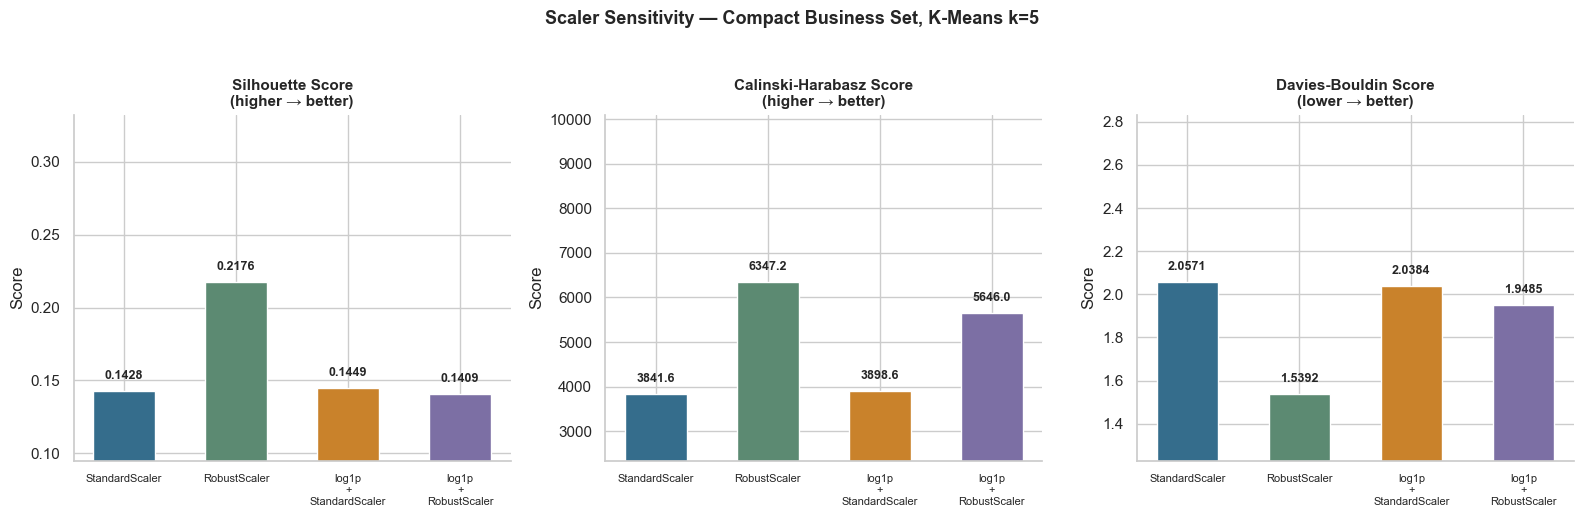

In [21]:
plot_order = list(scaler_results.keys())
colors = PALETTE[:len(plot_order)]

metrics_to_plot = [
    ("silhouette_score",        "Silhouette Score",        "higher → better"),
    ("calinski_harabasz_score", "Calinski-Harabasz Score", "higher → better"),
    ("davies_bouldin_score",    "Davies-Bouldin Score",    "lower → better"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, title, direction) in zip(axes, metrics_to_plot):
    values = [scaler_results[name][col] for name in plot_order]
    short_labels = [n.replace(" + ", "\n+\n") for n in plot_order]
    bars = ax.bar(short_labels, values, color=colors, width=0.55)
    span = max(values) - min(values) if max(values) != min(values) else max(values) * 0.01
    y_pad = span * 0.08
    for bar, v in zip(bars, values):
        fmt = f"{v:.4f}" if col != "calinski_harabasz_score" else f"{v:.1f}"
        ax.text(bar.get_x() + bar.get_width() / 2, v + y_pad, fmt,
                ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_ylim(min(values) - span * 0.6, max(values) + span * 1.5)
    ax.set_title(f"{title}\n({direction})", fontsize=11)
    ax.set_ylabel("Score")
    ax.tick_params(axis="x", labelsize=8)

fig.suptitle("Scaler Sensitivity — Compact Business Set, K-Means k=5",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

## Conclusion

RobustScaler wins on all three decision metrics by a clear margin (silhouette 0.2176, Calinski-Harabasz 6547.2, Davies-Bouldin 1.5392). The log1p variants do not improve over the baselines. **`03_preprocessing` should be updated to use RobustScaler as the confirmed scaler going forward.**

## Save Confirmed Pipeline Output

RobustScaler + compact business set is confirmed. Overwrite `selected_model_features.csv` with the updated preprocessing.

In [23]:
NUMERIC_COLS = COMPACT_NUMERIC_COLS  # already defined above

confirmed_X = scaled_datasets["RobustScaler"].copy()
confirmed_X.insert(0, "customer_id", raw["customer_id"].values)

confirmed_X.to_csv("data/processed/selected_model_features.csv", index=False)
print(f"Saved selected_model_features.csv")
print(f"Rows: {confirmed_X.shape[0]:,}")
print(f"Features: {confirmed_X.shape[1] - 1}")
print(f"Scaler: RobustScaler")
print(f"Feature set: compact business set (no categorical dummies)")
confirmed_X.head()

Saved selected_model_features.csv
Rows: 33,038
Features: 20
Scaler: RobustScaler
Feature set: compact business set (no categorical dummies)


,customer_id,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,typical_hour,age,customer_tenure,has_loyalty_card,total_children_home,...,share_groceries,share_electronics,share_vegetables,share_nonalcohol_drinks,share_alcohol_drinks,share_meat,share_fish,share_hygiene,share_videogames,share_petfood
0,3,0.0,0.0,0.461538,1.147251,0.000,0.03125,-0.714286,0.0,0.0,...,-0.350008,1.556431,-0.034449,-0.096317,-0.432541,-0.956394,-0.432012,-0.038953,0.304556,0.392400
1,4,-1.0,-0.5,0.048951,-0.262009,0.000,-0.12500,0.285714,0.0,-1.0,...,-0.130392,-0.254970,1.700878,0.440933,-0.591465,-0.936412,-0.815459,1.696860,0.530206,1.256560
2,5,0.0,-0.5,-0.293706,-0.498290,-0.125,0.00000,1.428571,-1.0,-2.0,...,0.450655,-0.691895,0.307231,-0.748057,-0.496175,1.621038,-0.213760,0.041029,-0.306310,-0.059029
3,7,1.0,-1.0,-0.216783,0.041426,0.750,-0.34375,-0.857143,0.0,-2.0,...,-0.973212,-0.013467,-0.350277,1.895790,1.749301,1.093357,1.749713,0.036376,8.447787,-0.198545
4,8,2.0,-1.0,-0.818182,-0.154704,0.625,0.06250,-0.857143,0.0,-2.0,...,-1.668903,3.165917,-0.151063,0.237569,0.170477,0.331328,0.565851,-0.538095,3.242873,0.140370
